#lab1

**выполнил: Тихомиров Максим**

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, cross_val_score, LeaveOneOut, train_test_split
from sklearn.linear_model import LinearRegression
from typing import Callable, Optional, Tuple



RANDOM_STATE = 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [88]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data/train.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


In [89]:
test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data/test.csv")
test.head()

,ID,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,...,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,0,1979-01-03,49,207095,850,14458,60,Single,0,Rent,...,0.883232,6,Employed,High School,23,10626,0.104458,0.125350,325.532336,0.040650
1,1,2006-04-10,28,64653,674,65491,48,Single,2,Own,...,0.791928,3,Employed,High School,3,299024,0.233491,0.260561,2210.247757,0.454410
2,2,2013-11-28,41,300000,768,16811,60,Single,1,Own,...,0.805826,3,Employed,High School,19,6979,0.147811,0.154571,403.977431,0.034919
3,3,1995-08-24,50,300000,850,48737,36,Divorced,0,Mortgage,...,0.829294,3,Self-Employed,Bachelor,26,8438,0.118737,0.099712,1571.946906,0.085558
4,4,1980-06-15,35,300000,672,51916,60,Single,6,Mortgage,...,0.735013,7,Employed,Associate,12,436216,0.230916,0.237727,1486.675235,0.063707


#EDA

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [91]:
df.isnull().sum()

,0
ApplicationDate,530
Age,530
AnnualIncome,530
CreditScore,1031
LoanAmount,1031
LoanDuration,530
MaritalStatus,530
NumberOfDependents,530
HomeOwnershipStatus,530
MonthlyDebtPayments,1031


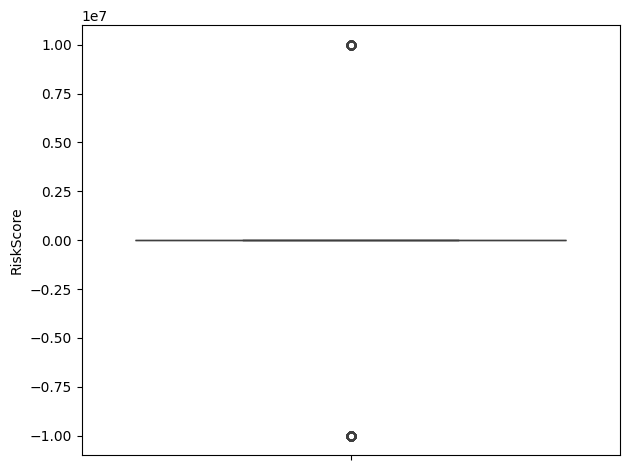

In [92]:

sns.boxplot(df["RiskScore"])
plt.tight_layout()
plt.show()

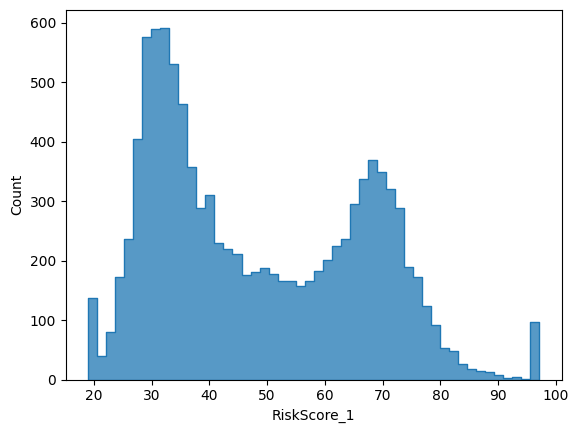

In [93]:
df1 = df.copy()

df_eda = pd.to_numeric(df1["RiskScore"], errors="coerce").replace([np.inf, -np.inf], np.nan)
low, high = df_eda.quantile(
    [0.012, 0.991]
)
df1["RiskScore_1"] = df_eda.clip(lower=low, upper=high)
sns.histplot(df1["RiskScore_1"].dropna(), bins=50, element="step")
plt.show()

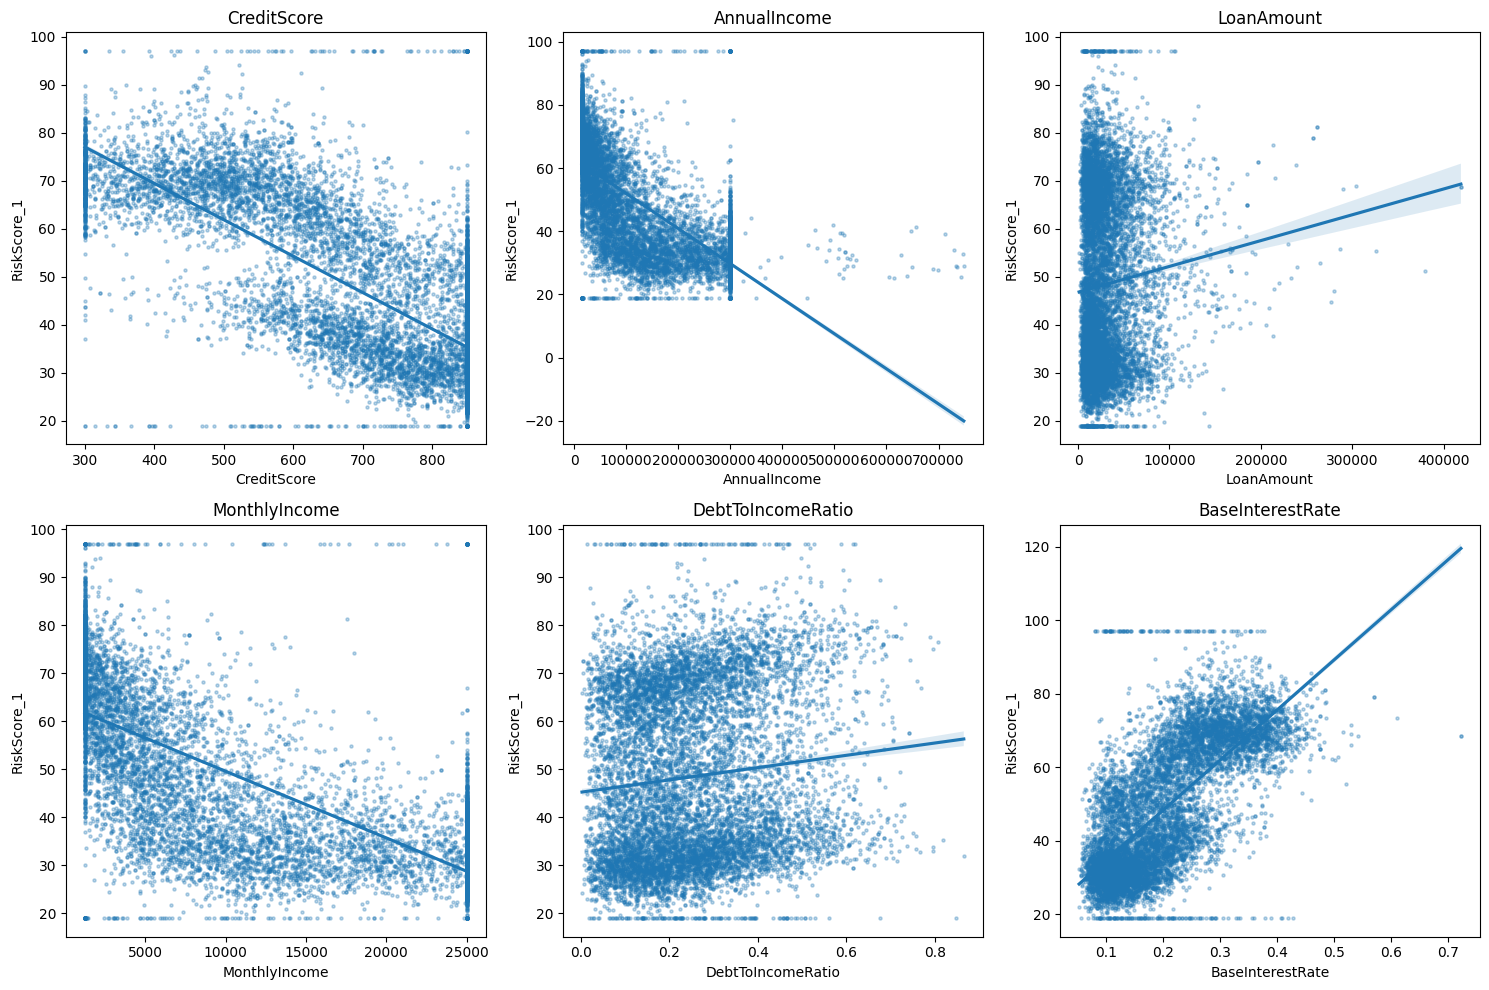

In [94]:
variabels = [
    "CreditScore",
    "AnnualIncome",
    "LoanAmount",
    "MonthlyIncome",
    "DebtToIncomeRatio",
    "BaseInterestRate"

]

fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.ravel()
for ax, col in zip(axes, variabels):
  df_eda = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
  sns.regplot(x=df_eda, y=df1["RiskScore_1"],scatter_kws={"alpha": 0.3, "s": 5},ax=ax)

  ax.set_title(col)

plt.tight_layout()
plt.show()

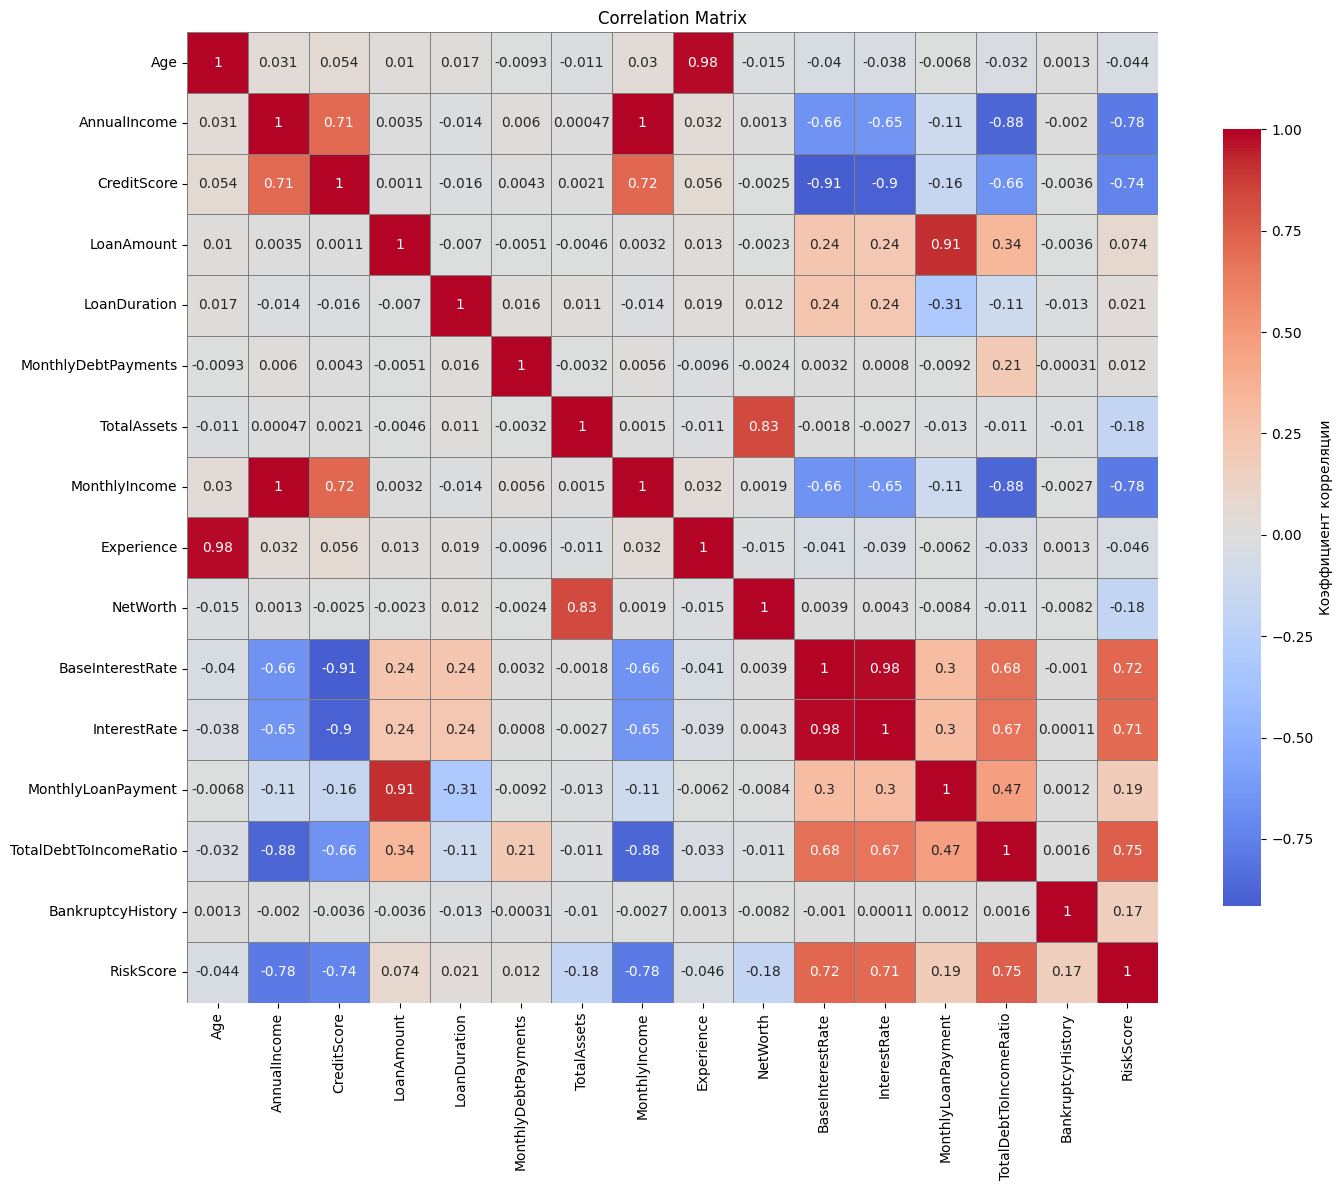

In [95]:
numeric_cols = df.select_dtypes(include=['number']).replace([np.inf, -np.inf], np.nan)

col_cor = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration',
                     'MonthlyDebtPayments', 'TotalAssets', 'MonthlyIncome', 'Experience',
                     'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
                     'TotalDebtToIncomeRatio', 'BankruptcyHistory', 'RiskScore']

corr = numeric_cols[col_cor].corr(method='spearman')

plt.figure(figsize=(15, 12))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
            linewidths=0.5,
            linecolor='gray')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [96]:
class myZscore:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        return self

    def transform(self, X):

        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class myMinMax:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        range_ = self.max_ - self.min_
        range_[range_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [97]:

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

y_true_test = np.array([10.5, 5.0, 15.2, 0.8, 20.0])
y_pred_test = np.array([10.6, 4.9, 15.0, 0.9, 20.1])

print("\nMSE:")
print(f"My: {mse(y_true_test, y_pred_test):.3f}")
print(f"Sklearn: {mean_squared_error(y_true_test, y_pred_test):.3f}")

print("\nMAE:")
print(f"My: {mae(y_true_test, y_pred_test):.3f}")
print(f"Sklearn: {mean_absolute_error(y_true_test, y_pred_test):.3f}")

print("\nR²:")
print(f"My: {r2(y_true_test, y_pred_test):.3f}")
print(f"Sklearn: {r2_score(y_true_test, y_pred_test):.3f}")

print("\nMAPE:")
print(f"My: {mape(y_true_test, y_pred_test):.3f}%")
print(f"Sklearn: {(mean_absolute_percentage_error(y_true_test, y_pred_test) * 100):.3f}%")


MSE:
My: 0.016
Sklearn: 0.016

MAE:
My: 0.120
Sklearn: 0.120

R²:
My: 1.000
Sklearn: 1.000

MAPE:
My: 3.454%
Sklearn: 3.454%


In [98]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=32,
                 method_type='analytical', reg_type=None, lambda_l2=0.001):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.batch_size = batch_size
        self.method_type = method_type
        self.reg_type = reg_type
        self.lambda_l2 = lambda_l2
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        if self.method_type == 'analytical':
            self.fit_analytical(X, y)
        elif self.method_type == 'gd':
            self.fit_gd(X, y)
        elif self.method_type == 'sgd':
            self.fit_sgd(X, y)

    def fit_analytical(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        if self.reg_type == "l2":
            n_features = X_b.shape[1]
            regularization = self.lambda_l2 * np.eye(n_features)
            regularization[0, 0] = 0

        try:
            if self.reg_type == "l2":
                X_b_T_X_b_inv = np.linalg.pinv(X_b.T @ X_b + regularization)
            else:
                X_b_T_X_b_inv = np.linalg.pinv(X_b.T @ X_b)

            theta = X_b_T_X_b_inv @ X_b.T @ y
        except np.linalg.LinAlgError:
            return

        self.bias = theta[0]
        self.weights = theta[1:]

    def fit_gd(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for iteration in range(self.n_iters):
            y_pred = X @ self.weights + self.bias

            if self.reg_type == "l2":
                dw = (1 / n_samples) * (X.T @ (y_pred - y)) + self.lambda_l2 * self.weights
            else:
                dw = (1 / n_samples) * (X.T @ (y_pred - y))

            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if iteration % 100 == 0:
                if self.reg_type == "l2":
                    l2_penalty = self.lambda_l2 * np.sum(self.weights ** 2)
                    loss = mse(y, y_pred) + l2_penalty
                else:
                    loss = mse(y, y_pred)
                self.loss_history.append(loss)

    def fit_sgd(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for iteration in range(self.n_iters):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = X_batch @ self.weights + self.bias
                batch_size_actual = X_batch.shape[0]

                if self.reg_type == "l2":
                    dw = (1 / batch_size_actual) * (X_batch.T @ (y_pred - y_batch)) + self.lambda_l2 * self.weights
                else:
                    dw = (1 / batch_size_actual) * (X_batch.T @ (y_pred - y_batch))

                db = (1 / batch_size_actual) * np.sum(y_pred - y_batch)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            if iteration % 100 == 0:
                y_pred_all = X @ self.weights + self.bias
                if self.reg_type == "l2":
                    l2_penalty = self.lambda_l2 * np.sum(self.weights ** 2)
                    loss = mse(y, y_pred_all) + l2_penalty
                else:
                    loss = mse(y, y_pred_all)
                self.loss_history.append(loss)

    def predict(self, X):
        return X @ self.weights + self.bias

In [99]:
def norm(s):
    return (s - s.min()) / (s.max() - s.min())


def make_features(df_in):
    df = df_in.copy()

    df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
    min_date = pd.Timestamp("1970-01-01")
    df["AppYear"] = df["ApplicationDate"].dt.year
    df["AppMonth"] = df["ApplicationDate"].dt.month
    df["AppDays"] = (df["ApplicationDate"] - min_date).dt.days

    fill_cols = ["AnnualIncome", "TotalAssets", "TotalLiabilities", "NetWorth"]
    for c in fill_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())

    df["Income_per_person"] = df["AnnualIncome"] / (df["NumberOfDependents"] + 1)
    df["Liabilities_to_Income"] = df["TotalLiabilities"] / (df["AnnualIncome"] + 10)
    df["Assets_to_Income"] = df["TotalAssets"] / (df["AnnualIncome"] + 10)
    df["Savings_to_Income"] = df["SavingsAccountBalance"] / (df["AnnualIncome"] + 10)

    for col in [
        "AnnualIncome",
        "LoanAmount",
        "TotalAssets",
        "TotalLiabilities",
        "NetWorth",
    ]:
        if col in df.columns:
            min_val = df[col].min()
            shift = abs(min_val) + 1.0 if min_val < 0 else 1.0
            df[f"log_{col}"] = np.log(df[col] + shift)

    df["Interest_Spread"] = df["InterestRate"] - df["BaseInterestRate"]
    df["CreditScore_sq"] = df["CreditScore"] ** 2

    df["Total_Payment_to_Income"] = (
                                            df["MonthlyDebtPayments"] + df["MonthlyLoanPayment"]
                                    ) / (df["MonthlyIncome"] + 10)
    df["Asset_Coverage"] = df["TotalAssets"] / (df["TotalLiabilities"] + 10)
    df["Negative_NetWorth"] = (df["NetWorth"] < 0).astype(int)
    df['Age_Bin'] = pd.qcut(df['Age'], q=5, labels=False, duplicates='drop')
    df['Income_Bin'] = pd.qcut(df['AnnualIncome'], q=5, labels=False, duplicates='drop')
    df['Dist_to_Bad'] = np.sqrt(
        norm(df['CreditScore']) ** 2 +
        norm(df['AnnualIncome']) ** 2 +
        (1 - norm(df['DebtToIncomeRatio'])) ** 2
    )

    df['Dist_to_Good'] = np.sqrt(
        (1 - norm(df['CreditScore'])) ** 2 +
        (1 - norm(df['AnnualIncome'])) ** 2 +
        norm(df['DebtToIncomeRatio']) ** 2
    )

    try:
        df['CreditScore_Bin'] = pd.qcut(df['CreditScore'], q=10, labels=False, duplicates='drop')
    except:
        pass


    df['LoanAmount_Bin'] = pd.qcut(df['LoanAmount'], q=10, labels=False, duplicates='drop')

    df['DTI_Bin'] = pd.qcut(df['DebtToIncomeRatio'], q=10, labels=False, duplicates='drop')

    df['Duration_Cat'] = df['LoanDuration'].astype(int).astype(str)

    try:
        df['NetWorth_Bin'] = pd.qcut(df['NetWorth'], q=5, labels=False, duplicates='drop')
    except:
        pass

    return df

In [100]:

low_q = df["RiskScore"].quantile(0.012)
high_q = df["RiskScore"].quantile(0.991)
df_clean = df[(df["RiskScore"] >= low_q) & (df["RiskScore"] <= high_q)].reset_index(
    drop=True
)


df_train_fe = make_features(df_clean)
df_test_fe = make_features(test)

te_cols = ["EducationLevel", "EmploymentStatus", "HomeOwnershipStatus", "LoanPurpose", "Age_Bin", "Income_Bin",
           "CreditScore_Bin", "LoanAmount_Bin", "DTI_Bin", "Duration_Cat", "NetWorth_Bin"]
global_mean = df_clean["RiskScore"].median()

for col in te_cols:
    means = df_train_fe.groupby(col)["RiskScore"].median()

    df_train_fe[f"{col}_TE"] = df_train_fe[col].map(means).fillna(global_mean)
    df_test_fe[f"{col}_TE"] = df_test_fe[col].map(means).fillna(global_mean)

cat_cols = [
    "MaritalStatus",
    "EmploymentStatus",
    "EducationLevel",
    "LoanPurpose",
    "HomeOwnershipStatus",
    "Age_Bin",
    "Income_Bin",
    "NetWorth_Bin"

]
exclude_cols = ["RiskScore", "Id", "ID", "ApplicationDate"] + cat_cols
num_cols = [
    c
    for c in df_train_fe.select_dtypes(include=["number"]).columns
    if c not in exclude_cols
]

X_train_cat = pd.get_dummies(df_train_fe[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(df_test_fe[cat_cols], drop_first=True)

X_train_cat, X_test_cat = X_train_cat.align(
    X_test_cat, join="left", axis=1, fill_value=0
)

X_train_num = df_train_fe[num_cols].fillna(0).values
X_test_num = df_test_fe[num_cols].fillna(0).values
y = df_train_fe["RiskScore"].values

var_filter = VarianceThreshold(threshold=0)
X_train_num = var_filter.fit_transform(X_train_num)
X_test_num = var_filter.transform(X_test_num)


In [101]:

correlations = []
for i in range(X_train_num.shape[1]):
    corr = np.corrcoef(X_train_num[:, i], y)[0, 1]
    if np.isnan(corr):
        corr = 0
    correlations.append(abs(corr))

top_20_idx = np.argsort(correlations)[-20:]
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train_num[:, top_20_idx])[:, 20:]
X_test_p2 = poly2.transform(X_test_num[:, top_20_idx])[:, 20:]

top_5_idx = np.argsort(correlations)[-5:]
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_p3_raw = poly3.fit_transform(X_train_num[:, top_5_idx])
X_test_p3_raw = poly3.transform(X_test_num[:, top_5_idx])

n_deg2 = PolynomialFeatures(degree=2).fit(X_train_num[:, top_5_idx]).n_output_features_ - 1
X_train_p3 = X_train_p3_raw[:, n_deg2:]
X_test_p3 = X_test_p3_raw[:, n_deg2:]
X_full_train = np.hstack([X_train_num, X_train_p2, X_train_p3, X_train_cat.values])
X_full_test = np.hstack([X_test_num, X_test_p2, X_test_p3, X_test_cat.values])

X_full_train = np.nan_to_num(X_full_train, nan=0.0).astype(np.float64)
X_full_test = np.nan_to_num(X_full_test, nan=0.0).astype(np.float64)

scaler = myZscore()
X_scaled_train = scaler.fit_transform(X_full_train)
X_scaled_test = scaler.transform(X_full_test)

sel_model = MyLinearRegression(learning_rate=0.1)
sel_model.fit_analytical(X_scaled_train, y)
weights = np.abs(sel_model.weights[1:])

top_idx = np.argsort(weights)[-285:]
X_tr = X_scaled_train[:, top_idx]
X_te = X_scaled_test[:, top_idx]

In [102]:
my_zScore = myZscore()
X_z = my_zScore.fit_transform(X_full_train)

my_minmaxScore = myMinMax()
X_mm = my_minmaxScore.fit_transform(X_full_train)

scaler_z_skl = StandardScaler()
scaler_mm_skl = MinMaxScaler()

X_z_skl = scaler_z_skl.fit_transform(X_full_train)
X_mm_skl = scaler_mm_skl.fit_transform(X_full_train)

print("z-score diff:", np.max(np.abs(X_z - X_z_skl)))
print("min-max diff:", np.max(np.abs(X_mm - X_mm_skl)))

z-score diff: 0.0
min-max diff: 6.439293542825908e-15


In [105]:
def k_fold_cv(
    model_class,
    X: np.ndarray,
    y: np.ndarray,
    k: int = 5,
    scoring: Optional[Callable] = None,
    random_state: Optional[int] = None,
    **model_params
):
    n = len(y)
    scores = []
    oof_pred = np.zeros(n)

    rng = np.random.default_rng(random_state)
    indices = rng.permutation(n)

    fold_sizes = np.full(k, n // k, dtype=int)
    fold_sizes[:n % k] += 1

    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size

        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = model_class(**model_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        oof_pred[val_idx] = y_pred

        if scoring is None:
            score = np.mean((y_val - y_pred) ** 2)
        else:
            score = scoring(y_val, y_pred)

        scores.append(score)
        start = end

    return np.array(scores), oof_pred


def leave_one_out_cv(
    model_class,
    X: np.ndarray,
    y: np.ndarray,
    scoring: Optional[Callable] = None,
    **model_params
):
    if scoring is None:
        def scoring(y_true, y_pred):
            return np.mean((y_true - y_pred) ** 2)

    n_samples = len(y)
    predictions = np.zeros(n_samples)

    for i in range(n_samples):
        train_idx = np.delete(np.arange(n_samples), i)
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[i:i+1], y[i:i+1]

        model = model_class(**model_params)
        model.fit(X_train, y_train)

        predictions[i] = model.predict(X_val)[0]

    score = scoring(y, predictions)
    return score, predictions

In [107]:
print("=== Демонстрация Кросс-валидации на случайных данных ===")

np.random.seed(42)
X_cv_test = np.random.rand(50, 2)
true_weights = np.array([3.0, -2.0])
y_cv_test = X_cv_test @ true_weights + np.random.normal(0, 0.1, 50)

print("\n--- Сравнение K-Fold (k=5) ---")

my_cv_scores, my_oof_pred = k_fold_cv(
    MyLinearRegression,
    X_cv_test,
    y_cv_test,
    k=5,
    method_type='analytical'
)

kf = KFold(n_splits=5, shuffle=False)
sk_cv_results = cross_val_score(
    LinearRegression(),
    X_cv_test,
    y_cv_test,
    cv=kf,
    scoring='neg_mean_squared_error'
)
sk_cv_results = -sk_cv_results

print(f"Мои MSE по фолдам (MyLinearRegression): {my_cv_scores}")
print(f"Sklearn MSE по фолдам (Sklearn LinearRegression): {sk_cv_results}")
print(f"Средний MSE (My): {my_cv_scores.mean():.6f}")
print(f"Средний MSE (Sklearn): {sk_cv_results.mean():.6f}")
print(f"Разница средних: {abs(my_cv_scores.mean() - sk_cv_results.mean()):.10f}")

print("\n--- Сравнение Leave-One-Out ---")

my_loo_score, my_loo_pred = leave_one_out_cv(
    MyLinearRegression,
    X_cv_test,
    y_cv_test,
    method_type='analytical'
)

loo = LeaveOneOut()
sk_loo_results = cross_val_score(
    LinearRegression(),
    X_cv_test,
    y_cv_test,
    cv=loo,
    scoring='neg_mean_squared_error'
)
sk_loo_results = -sk_loo_results

print(f"MSE (My LOO): {my_loo_score:.6f}")
print(f"MSE (Sklearn LOO): {sk_loo_results.mean():.6f}")

=== Демонстрация Кросс-валидации на случайных данных ===

--- Сравнение K-Fold (k=5) ---
Мои MSE по фолдам (MyLinearRegression): [0.0077909  0.00616419 0.00566802 0.01793229 0.00749807]
Sklearn MSE по фолдам (Sklearn LinearRegression): [0.00726575 0.00469531 0.00502085 0.01295423 0.01341147]
Средний MSE (My): 0.009011
Средний MSE (Sklearn): 0.008670
Разница средних: 0.0003411754

--- Сравнение Leave-One-Out ---
MSE (My LOO): 0.009199
MSE (Sklearn LOO): 0.009199


In [108]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y, test_size=0.2, random_state=42
)

my_model = MyLinearRegression()
my_model.fit_analytical(X_train, y_train)
y_pred_my = my_model.predict(X_val)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_val)

print("=== MyLinearRegression (normal) ===")
print(f"MSE : {mse(y_val, y_pred_my):.4f}")
print(f"MAE : {mae(y_val, y_pred_my):.4f}")
print(f"R2  : {r2(y_val, y_pred_my):.4f}")
print(f"MAPE: {mape(y_val, y_pred_my):.4f}")

print("\n=== sklearn.LinearRegression ===")
print(f"MSE : {mean_squared_error(y_val, y_pred_sk):.4f}")
print(f"MAE : {mean_absolute_error(y_val, y_pred_sk):.4f}")
print(f"R2  : {r2_score(y_val, y_pred_sk):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_val, y_pred_sk):.4f}")

=== MyLinearRegression (normal) ===
MSE : 31.1677
MAE : 4.0379
R2  : 0.8975
MAPE: 9.3532

=== sklearn.LinearRegression ===
MSE : 30.9236
MAE : 4.0363
R2  : 0.8983
MAPE: 0.0935


In [109]:
for method_type in ["analytical", "gd", "sgd"]:
    scores, _ = k_fold_cv(
        MyLinearRegression,
        X_tr,
        y,
        k=5,
        method_type=method_type,
        learning_rate=1e-3,
        n_iters=3000,
        batch_size=32,
    )
    print(method_type, "k-fold MSE:", scores.mean(), "+/-", scores.std())

analytical k-fold MSE: 28.442994519766593 +/- 0.5301355092184707
gd k-fold MSE: 39.13808689115611 +/- 2.18219232250971
sgd k-fold MSE: 29.374998063380552 +/- 1.3578614261702797


In [112]:
final_model = MyLinearRegression(method_type='analytical', reg_type="l2", lambda_l2=0.001)
final_model.fit(X_tr, y)

preds = final_model.predict(X_te)

sub = pd.DataFrame({"ID": test["ID"], "RiskScore": preds})
sub.to_csv("submission.csv", index=False)
sub.head()

,ID,RiskScore
0,0,35.473768
1,1,54.672760
2,2,30.186109
3,3,36.411337
4,4,34.600465
